# Median ΔΔG (Stacking Free Energy) Across Generations

For each LTEE generation, compute the median nearest-neighbor stacking ΔΔG of mutations present at that timepoint. This parallels the generation-wise median kGain analysis.

In [1]:
"""Resolve project root dynamically for portable imports and data paths."""
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "utility.py").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "utility.py").exists():
    raise RuntimeError("Could not locate project root containing utility.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
import matplotlib.font_manager as fm
import warnings
import utility

# Keep default warning behavior for numerical/data issues during analysis.
pd.set_option('mode.chained_assignment', None)

# Use Arial if available, otherwise fall back to DejaVu Sans
_available_fonts = {f.name for f in fm.fontManager.ttflist}
_font_family = 'Arial' if 'Arial' in _available_fonts else 'DejaVu Sans'

plt.rcParams.update({
    'font.size': 11,
    'font.family': _font_family,
    'axes.linewidth': 1.2,
    'figure.dpi': 150,
})

print(f'Setup complete. Font: {_font_family}')



Setup complete. Font: DejaVu Sans


In [2]:
def strip_whitespace_from_string_columns(input_df):
    """
    Returns a copy of the DataFrame with leading and trailing whitespace removed
    from all string/object columns.
    
    Args:
        input_df (pd.DataFrame): Input DataFrame to process.
    
    Returns:
        pd.DataFrame: Copy with whitespace stripped from all string columns.
    """
    cleaned_df = input_df.copy()
    for column in cleaned_df.select_dtypes(include=['object', 'string']):
        cleaned_df[column] = cleaned_df[column].str.strip()
    return cleaned_df

## 1. Nearest-Neighbor Stacking Parameters & ΔΔG Computation

In [3]:
# SantaLucia (1998) nearest-neighbor stacking free energies (kcal/mol, 37°C, 1M NaCl)
NN_DG = {
    'AA': -1.00, 'TT': -1.00,
    'AT': -0.88,
    'TA': -0.58,
    'CA': -1.45, 'TG': -1.45,
    'GT': -1.44, 'AC': -1.44,
    'CT': -1.28, 'AG': -1.28,
    'GA': -1.30, 'TC': -1.30,
    'CG': -2.17,
    'GC': -2.24,
    'GG': -1.84, 'CC': -1.84,
}

def compute_nn_dg(seq):
    """Compute nearest-neighbor stacking free energy for a DNA sequence."""
    seq = seq.upper()
    dg = 0.0
    n_valid = 0
    for i in range(len(seq) - 1):
        dinuc = seq[i:i+2]
        if dinuc in NN_DG:
            dg += NN_DG[dinuc]
            n_valid += 1
    return dg if n_valid > 0 else np.nan

print('ΔG function defined.')

ΔG function defined.


## 1.5 Setup for Evolved ΔΔG (Generation 57500)

In [4]:
import kaos

fasta_file_path = str(DATA_DIR / "GCF_000017985.1_ASM1798v1_genomic.fna")
kmer_length = 10
flank_size = kmer_length - 1  # 9 bases flanking each side of the mutation


def mutate_fasta_by_generation(
    variant_data: pd.DataFrame,
    fasta_file_path: str,
    target_generation: int
) -> str:
    """
    Returns a mutated FASTA sequence for a specific generation,
    substituting alternate alleles at given positions.

    Notes:
        This helper currently supports single-contig FASTA content as returned by kaos.read_fasta.
        If multiple chromosomes/contigs are present in variant_data, it raises an error.

    Args:
        variant_data (pd.DataFrame): DataFrame with columns
            ['#CHROM', 'POS', 'REF', 'ALT', 'generation_number'].
        fasta_file_path (str): Path to the reference genome FASTA file.
        target_generation (int): The generation number to apply mutations for.

    Returns:
        str: Mutated DNA sequence as a string.

    Raises:
        ValueError: If required columns are missing or invalid SNP records are detected.
    """
    import kaos

    required_cols = ['#CHROM', 'POS', 'REF', 'ALT', 'generation_number']
    missing_cols = [col for col in required_cols if col not in variant_data.columns]
    if missing_cols:
        raise ValueError(
            f"Input DataFrame is missing required columns: {', '.join(missing_cols)}.\n"
            f"Columns found: {list(variant_data.columns)}"
        )

    variant_data = variant_data.copy()

    # Drop duplicate variant entries once and report count.
    before = variant_data.shape[0]
    variant_data = variant_data.drop_duplicates(subset=required_cols).reset_index(drop=True)
    after = variant_data.shape[0]
    if after < before:
        print(f"[Warning] Dropped {before - after} duplicate variant(s) based on columns {required_cols}.")

    # Read the reference sequence from FASTA.
    reference_seq = kaos.read_fasta(fasta_file_path)

    # Filter mutations for the target generation.
    relevant_variants = variant_data[variant_data["generation_number"] == target_generation].copy()

    if relevant_variants.empty:
        return reference_seq

    # Guard: this implementation mutates a single sequence string.
    unique_chrom = relevant_variants['#CHROM'].astype(str).str.strip().unique()
    if len(unique_chrom) > 1:
        raise ValueError(
            "mutate_fasta_by_generation currently supports one contig/chromosome at a time; "
            f"found multiple #CHROM values: {list(unique_chrom)}"
        )

    mutated_seq = list(reference_seq)

    for _, row in relevant_variants.iterrows():
        pos = int(row['POS'])
        ref = str(row['REF']).strip().upper()
        alt = str(row['ALT']).strip().upper()

        if len(ref) != 1 or len(alt) != 1:
            raise ValueError(f"Only SNPs are supported. Found REF={ref}, ALT={alt} at POS={pos}.")

        seq_index = pos - 1  # 1-based to 0-based
        if not (0 <= seq_index < len(mutated_seq)):
            raise ValueError(f"POS={pos} is out of range for sequence length {len(mutated_seq)}")

        if str(mutated_seq[seq_index]).upper() != ref:
            print(f"[Warning] REF mismatch at POS={pos}: expected {ref}, found {mutated_seq[seq_index]}. Skipping.")
            continue

        mutated_seq[seq_index] = alt

    return ''.join(mutated_seq)


def compute_evolved_flank_ddg(
    mutations_df: pd.DataFrame,
    evolved_fasta: str,
    flank_size: int,
) -> pd.DataFrame:
    """Compute evolved ddG in evolved local sequence context with strict full-length flank requirement."""
    records = []
    expected_len = 2 * flank_size + 1

    for _, row in mutations_df.iterrows():
        pos = int(row['POS']) - 1
        ref = str(row['REF']).strip().upper()
        alt = str(row['ALT']).strip().upper()

        if len(ref) != 1 or len(alt) != 1 or not (0 <= pos < len(evolved_fasta)):
            records.append({'unique_mutation_key': row['unique_mutation_key'], 'evolved_ddG': np.nan})
            continue

        start = max(0, pos - flank_size)
        end = min(len(evolved_fasta), pos + flank_size + 1)
        evolved_flank = evolved_fasta[start:end]

        # Strict parity with full-window methods: skip boundaries lacking full flank.
        if len(evolved_flank) != expected_len:
            records.append({'unique_mutation_key': row['unique_mutation_key'], 'evolved_ddG': np.nan})
            continue

        center = flank_size
        ref_flank = evolved_flank[:center] + ref + evolved_flank[center + 1:]
        mut_flank = evolved_flank[:center] + alt + evolved_flank[center + 1:]

        dg_ref = compute_nn_dg(ref_flank)
        dg_mut = compute_nn_dg(mut_flank)
        records.append({'unique_mutation_key': row['unique_mutation_key'], 'evolved_ddG': dg_mut - dg_ref})

    return pd.DataFrame(records)


def compute_evolved_flank_kgain(
    mutations_df: pd.DataFrame,
    evolved_fasta: str,
    evolved_fcgr_dict: dict,
    flank_size: int,
    kmer_length: int,
) -> pd.DataFrame:
    """
    Compute evolved kGain in the evolved local sequence context.

    Flanks are extracted from evolved FASTA (capturing neighboring accumulated mutations).
    Center base is forced to REF for reference flank and ALT for mutated flank.
    Requires full-length flank to mirror strict full-window behavior.
    """
    records = []
    expected_len = 2 * flank_size + 1

    for _, row in mutations_df.iterrows():
        pos = int(row['POS']) - 1
        ref = str(row['REF']).strip().upper()
        alt = str(row['ALT']).strip().upper()

        if len(ref) != 1 or len(alt) != 1:
            records.append({'unique_mutation_key': row['unique_mutation_key'], 'evolved_kGain': np.nan})
            continue

        if not (0 <= pos < len(evolved_fasta)):
            records.append({'unique_mutation_key': row['unique_mutation_key'], 'evolved_kGain': np.nan})
            continue

        start = max(0, pos - flank_size)
        end = min(len(evolved_fasta), pos + flank_size + 1)
        evolved_flank = evolved_fasta[start:end]

        # Strict parity with full-window methods: skip boundaries lacking full flank.
        if len(evolved_flank) != expected_len:
            records.append({'unique_mutation_key': row['unique_mutation_key'], 'evolved_kGain': np.nan})
            continue

        center = flank_size
        ref_flank = evolved_flank[:center] + ref + evolved_flank[center + 1:]
        mut_flank = evolved_flank[:center] + alt + evolved_flank[center + 1:]

        window_gains = []
        for j in range(kmer_length):
            left = center - kmer_length + j + 1
            right = center + j + 1
            alt_window = mut_flank[left:right]
            ref_window = ref_flank[left:right]

            if len(alt_window) != kmer_length or len(ref_window) != kmer_length:
                continue

            alt_freq = evolved_fcgr_dict.get(alt_window)
            ref_freq = evolved_fcgr_dict.get(ref_window)
            if alt_freq is None or ref_freq is None or alt_freq <= 0 or ref_freq <= 0:
                continue

            window_gains.append(np.log(alt_freq / ref_freq))

        kgain = float(np.sum(window_gains)) if window_gains else np.nan
        records.append({'unique_mutation_key': row['unique_mutation_key'], 'evolved_kGain': kgain})

    return pd.DataFrame(records)


print(f'Functions defined. FASTA: {fasta_file_path}')


Functions defined. FASTA: /home/abhishekh/iScience code-20260404T073214Z-1-001/iScience code/code/data/GCF_000017985.1_ASM1798v1_genomic.fna


## 2. Load Data & Compute ΔΔG Per Mutation

In [5]:
# Load kGain data (has ref_flank_seq and mutated_flank_seq)
kgain_df = pd.read_csv(str(DATA_DIR / 'kgain_all_population_wt.csv'))
kgain_df = strip_whitespace_from_string_columns(kgain_df)

# Compute ΔΔG for each mutation
kgain_df['dG_ref'] = kgain_df['ref_flank_seq'].apply(lambda s: compute_nn_dg(str(s)))
kgain_df['dG_mut'] = kgain_df['mutated_flank_seq'].apply(lambda s: compute_nn_dg(str(s)))
kgain_df['ddG'] = kgain_df['dG_mut'] - kgain_df['dG_ref']

print(f'Computed ΔΔG for {kgain_df.shape[0]} mutations')
print(f'ΔΔG range: [{kgain_df["ddG"].min():.3f}, {kgain_df["ddG"].max():.3f}] kcal/mol')
print(f'Median ΔΔG: {kgain_df["ddG"].median():.4f}')
kgain_df[['POS', 'REF', 'ALT', 'population_label', 'wild_type_kGain', 'ddG']].head()

Computed ΔΔG for 36922 mutations
ΔΔG range: [-1.830, 1.830] kcal/mol
Median ΔΔG: -0.8900


,POS,REF,ALT,population_label,wild_type_kGain,ddG
0,851,C,T,m3,-8.764470,1.34
1,1521,C,T,m3,-11.203187,1.08
2,1612,A,G,m3,-2.844573,-1.08
3,3988,G,A,m3,-9.244451,1.10
4,6394,A,G,m3,7.647503,-1.43


## 3. Load Annotation Data & Build Generation-Wise Long Format

In [6]:
# Load annotation data with AC/DP per generation
annot_df = pd.read_csv(str(DATA_DIR / 'concat_pop_annotation.csv'))
annot_df.columns = annot_df.columns.str.strip()
annot_df = strip_whitespace_from_string_columns(annot_df)

# Identify AC and DP columns
ac_cols = sorted([c for c in annot_df.columns if c.startswith('AC:')],
                 key=lambda x: int(x.split(':')[1]))
dp_cols = sorted([c for c in annot_df.columns if c.startswith('DP:')],
                 key=lambda x: int(x.split(':')[1]))

# Keep only LTEE generations (<=60000)
ac_cols_ltee = [c for c in ac_cols if int(c.split(':')[1]) <= 60000]
dp_cols_ltee = [c for c in dp_cols if int(c.split(':')[1]) <= 60000]

print(f'Annotation data: {annot_df.shape[0]} mutations')
print(f'LTEE generation columns: {len(ac_cols_ltee)}')

Annotation data: 36923 mutations
LTEE generation columns: 117


In [7]:
# Parse kGain key into explicit fields to avoid hardcoded chromosome assumptions
kgain_key_parts = kgain_df['unique_mutation_key'].astype(str).str.split('_', expand=True)
if kgain_key_parts.shape[1] < 5:
    raise ValueError('unique_mutation_key must contain at least 5 underscore-delimited parts: CHROM_REF_POS_ALT_LABEL')

kgain_key_map = pd.DataFrame({
    '#CHROM': kgain_key_parts[0].astype(str).str.strip(),
    'Ref_allele': kgain_key_parts[1].astype(str).str.strip(),
    'Position': pd.to_numeric(kgain_key_parts[2], errors='coerce').astype('Int64'),
    'Alt_allele': kgain_key_parts[3].astype(str).str.strip(),
    'label': kgain_key_parts[4].astype(str).str.strip(),
    'unique_mutation_key': kgain_df['unique_mutation_key'].astype(str).str.strip(),
})

kgain_key_map = kgain_key_map.merge(
    kgain_df[['unique_mutation_key', 'ddG', 'wild_type_kGain']],
    on='unique_mutation_key',
    how='left'
)

# Collision guard: if merge keys map to multiple chromosomes, downstream merge is ambiguous.
key_cols_no_chrom = ['Ref_allele', 'Position', 'Alt_allele', 'label']
ambiguous = (
    kgain_key_map.groupby(key_cols_no_chrom)['#CHROM']
    .nunique()
    .reset_index(name='n_chrom')
)
ambiguous = ambiguous[ambiguous['n_chrom'] > 1]
if not ambiguous.empty:
    raise ValueError(
        f"Ambiguous merge keys found across multiple chromosomes for {len(ambiguous)} key(s). "
        "Include chromosome-resolved keys before merging."
    )

kgain_key_map = kgain_key_map.drop_duplicates(subset=['#CHROM', 'Ref_allele', 'Position', 'Alt_allele', 'label'])

annot_tmp = annot_df.copy()
annot_tmp['Position'] = pd.to_numeric(annot_tmp['Position'], errors='coerce').astype('Int64')

# Merge ΔΔG, WT kGain, and chromosome into annotation.
annot_with_ddg = annot_tmp.merge(
    kgain_key_map,
    on=['Ref_allele', 'Position', 'Alt_allele', 'label'],
    how='inner'
)

print(f'Merged: {annot_with_ddg.shape[0]} mutations with ΔΔG + generation data')

# Drop AC/DP generation columns that have NaN values (consistent with fig3.ipynb)
nan_ac = [c for c in ac_cols_ltee if annot_with_ddg[c].isna().any()]
nan_dp = [c for c in dp_cols_ltee if annot_with_ddg[c].isna().any()]
nan_gens = sorted(set(int(c.split(':')[1]) for c in nan_ac))
ac_cols_ltee = [c for c in ac_cols_ltee if c not in nan_ac]
dp_cols_ltee = [c for c in dp_cols_ltee if c not in nan_dp]

print(f'Dropped {len(nan_ac)} generations with NaN allele counts: {nan_gens}')
print(f'Remaining LTEE generation columns: {len(ac_cols_ltee)}')



Merged: 36923 mutations with ΔΔG + generation data
Dropped 8 generations with NaN allele counts: [2500, 15000, 46500, 58000, 58500, 59000, 59500, 60000]
Remaining LTEE generation columns: 109


In [8]:
# --- Evolved kGain and evolved ddG at generation 57500 ---
target_generation = 57500

# Build variant data for gen 57500 per population (mutations present at that generation)
variant_data_57500 = annot_with_ddg[annot_with_ddg['AC:57500'] > 0][[
    '#CHROM', 'Position', 'Ref_allele', 'Alt_allele', 'label', 'unique_mutation_key'
]].rename(columns={
    'Position': 'POS', 'Ref_allele': 'REF', 'Alt_allele': 'ALT', 'label': 'population_label'
}).copy()
variant_data_57500['generation_number'] = target_generation

# Build evolved FASTA per population (exact pattern from fig3.ipynb cell 16)
dct_fasta_pop_wise_target_generation_57500 = dict()
for population in set(annot_with_ddg['label'].unique()):
    individual_population_wise_mutation_counts, individual_population_wise_mutation_counts_for_selected_generation = [None] * 2
    individual_population_wise_mutation_counts = variant_data_57500[variant_data_57500['population_label'] == population]
    individual_population_wise_mutation_counts_for_selected_generation = individual_population_wise_mutation_counts[
        individual_population_wise_mutation_counts['generation_number'] == target_generation
    ]
    individual_population_wise_mutation_counts_for_selected_generation.reset_index(inplace=True, drop=True)
    dct_fasta_pop_wise_target_generation_57500[population] = mutate_fasta_by_generation(
        variant_data=individual_population_wise_mutation_counts_for_selected_generation,
        fasta_file_path=fasta_file_path,
        target_generation=target_generation
    )

# Compute evolved kGain + evolved ddG in evolved local sequence context
evolved_kgain_all = pd.DataFrame()
evolved_ddg_all = pd.DataFrame()

for population in set(annot_with_ddg['label'].unique()):
    pop_mutations = annot_with_ddg[annot_with_ddg['label'] == population][
        ['Position', 'Ref_allele', 'Alt_allele', 'unique_mutation_key']
    ].rename(columns={'Position': 'POS', 'Ref_allele': 'REF', 'Alt_allele': 'ALT'}).copy()

    evolved_fasta_str = dct_fasta_pop_wise_target_generation_57500[population]

    evolved_fcgr_dict = kaos.chaos_frequency_dictionary(
        fasta_string=evolved_fasta_str,
        kmer_length=kmer_length,
        pseudo_count=True,
        chaos_game_kmer_array=kaos.chaos_game_representation_key(kmer_length=kmer_length),
    )
    pop_evolved_kgain = compute_evolved_flank_kgain(
        mutations_df=pop_mutations,
        evolved_fasta=evolved_fasta_str,
        evolved_fcgr_dict=evolved_fcgr_dict,
        flank_size=flank_size,
        kmer_length=kmer_length,
    )
    pop_evolved_ddg = compute_evolved_flank_ddg(
        mutations_df=pop_mutations,
        evolved_fasta=evolved_fasta_str,
        flank_size=flank_size,
    )

    evolved_kgain_all = pd.concat([evolved_kgain_all, pop_evolved_kgain], ignore_index=True)
    evolved_ddg_all = pd.concat([evolved_ddg_all, pop_evolved_ddg], ignore_index=True)

# Re-runnable: drop old evolved columns if they exist
annot_with_ddg = annot_with_ddg.drop(columns=['evolved_kGain', 'evolved_ddG'], errors='ignore')

annot_with_ddg = annot_with_ddg.merge(
    evolved_kgain_all[['unique_mutation_key', 'evolved_kGain']].drop_duplicates(subset='unique_mutation_key'),
    on='unique_mutation_key',
    how='left',
)
annot_with_ddg = annot_with_ddg.merge(
    evolved_ddg_all[['unique_mutation_key', 'evolved_ddG']].drop_duplicates(subset='unique_mutation_key'),
    on='unique_mutation_key',
    how='left',
)

# Cross-check on evolved metrics
valid = annot_with_ddg[['evolved_ddG', 'evolved_kGain']].dropna()
if len(valid) > 2:
    rho, p = stats.spearmanr(valid['evolved_ddG'], valid['evolved_kGain'])
else:
    rho, p = np.nan, np.nan

print(f'Evolved kGain (gen {target_generation}) computed for {annot_with_ddg["evolved_kGain"].notna().sum()} / {len(annot_with_ddg)} mutations')
print(f'Evolved ddG (gen {target_generation}) computed for {annot_with_ddg["evolved_ddG"].notna().sum()} / {len(annot_with_ddg)} mutations')
print(f'Median evolved kGain: {annot_with_ddg["evolved_kGain"].median():.4f}')
print(f'Median evolved ddG:   {annot_with_ddg["evolved_ddG"].median():.4f}')
print(f'Median WT kGain:      {annot_with_ddg["wild_type_kGain"].median():.4f}')
print(f'Median WT ddG:        {annot_with_ddg["ddG"].median():.4f}')
print(f'Spearman (evolved_ddG vs evolved_kGain): rho={rho:.3f}, p={p:.2e}')

annot_with_ddg[['unique_mutation_key', 'ddG', 'evolved_ddG', 'wild_type_kGain', 'evolved_kGain']].head()



Evolved kGain (gen 57500) computed for 36923 / 36923 mutations
Evolved ddG (gen 57500) computed for 36923 / 36923 mutations
Median evolved kGain: -1.8897
Median evolved ddG:   -0.8900
Median WT kGain:      -3.4610
Median WT ddG:        -0.8900
Spearman (evolved_ddG vs evolved_kGain): rho=-0.397, p=0.00e+00


,unique_mutation_key,ddG,evolved_ddG,wild_type_kGain,evolved_kGain
0,chrI_C_1554_A_p1,1.83,1.83,-4.354439,-4.354439
1,chrI_C_1556_A_p1,1.39,1.39,-6.397929,-6.397929
2,chrI_G_2450_T_p1,1.39,1.39,-4.876287,-1.997167
3,chrI_C_4274_T_p1,1.34,1.34,-8.830618,-8.830618
4,chrI_T_6400_G_p1,-0.79,-0.79,-12.006786,-12.006786


In [9]:
# annot_with_ddg[annot_with_ddg["wild_type_kGain"]!=annot_with_ddg["evolved_kGain"]]

In [10]:
# Build long format: for each generation, find which mutations are present (AC > 0)
# and collect evolved-context ΔΔG and kGain values

generation_stats = []

for ac_col, dp_col in zip(ac_cols_ltee, dp_cols_ltee):
    gen = int(ac_col.split(':')[1])

    present = annot_with_ddg[annot_with_ddg[ac_col] > 0]

    if len(present) == 0:
        continue

    af = present[ac_col] / present[dp_col].replace(0, np.nan)

    kg_non_na = present['evolved_kGain'].notna().sum()
    se_kg = present['evolved_kGain'].std() / np.sqrt(kg_non_na) if kg_non_na > 0 else np.nan

    ddg_non_na = present['evolved_ddG'].notna().sum()
    se_ddg = present['evolved_ddG'].std() / np.sqrt(ddg_non_na) if ddg_non_na > 0 else np.nan

    generation_stats.append({
        'generation': gen,
        'n_mutations': len(present),
        'median_ddG': present['evolved_ddG'].median(),
        'mean_ddG': present['evolved_ddG'].mean(),
        'std_ddG': present['evolved_ddG'].std(),
        'se_ddG': se_ddg,
        'median_wt_ddG': present['ddG'].median(),
        'median_wt_kGain': present['wild_type_kGain'].median(),
        'median_kGain': present['evolved_kGain'].median(),
        'mean_kGain': present['evolved_kGain'].mean(),
        'se_kGain': se_kg,
        'median_af': af.median(),
    })

gen_df = pd.DataFrame(generation_stats)
print(f'Generation-wise stats computed for {len(gen_df)} generations')
print(f'Generation range: {gen_df["generation"].min()} to {gen_df["generation"].max()}')
gen_df.head(10)



Generation-wise stats computed for 109 generations
Generation range: 0 to 57500


,generation,n_mutations,median_ddG,mean_ddG,std_ddG,se_ddG,median_wt_ddG,median_wt_kGain,median_kGain,mean_kGain,se_kGain,median_af
0,0,1266,1.28,0.510182,1.229883,0.034566,1.28,-4.509264,-2.948613,-2.558034,0.150553,0.006667
1,1000,2908,-0.84,-0.480543,1.070439,0.019850,-0.84,-3.930372,-1.766798,-1.788422,0.102842,0.013514
2,1500,2806,-0.84,-0.130855,1.222500,0.023078,-0.84,-3.530628,-1.996363,-2.059671,0.104392,0.048038
3,2000,3560,-0.79,-0.121669,1.214290,0.020352,-0.79,-3.622524,-1.901832,-1.960768,0.091405,0.044544
4,3000,3559,-0.79,-0.124153,1.218122,0.020419,-0.79,-3.491392,-1.781359,-1.828879,0.090519,0.038462
5,4000,3497,-0.79,-0.056331,1.233244,0.020855,-0.79,-3.480209,-1.584120,-1.698122,0.093061,0.046154
6,4500,3669,-0.79,-0.069060,1.238928,0.020454,-0.79,-3.660669,-1.790702,-1.769259,0.090704,0.042553
7,5000,3668,-0.84,-0.125477,1.238568,0.020451,-0.84,-3.595369,-1.780023,-1.733338,0.091078,0.057143
8,5500,3921,-0.84,-0.139551,1.230363,0.019649,-0.84,-3.555348,-1.691072,-1.689839,0.087093,0.052632
9,6000,4007,-0.84,-0.211413,1.227549,0.019392,-0.84,-3.442019,-1.533598,-1.552578,0.086869,0.037037


## 4. Plot: Median ΔΔG and Median kGain Across Generations

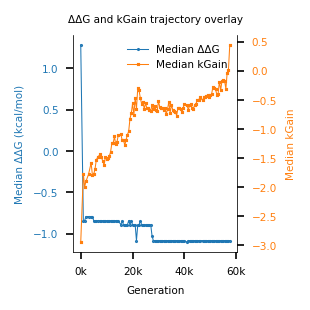

Spearman ρ = -0.6862, p = 1.80e-16


In [11]:
# ---- ΔΔG and kGain trajectory overlay (dual y-axis) ----
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42  # embeds fonts as vectors in PDF
matplotlib.rcParams['ps.fonttype']  = 42

fig, ax1 = plt.subplots(1, 1, figsize=(2.2, 2.2))

fs = 5
color1 = '#1f77b4'
color2 = '#ff7f0e'

ax1.plot(gen_df['generation'], gen_df['median_ddG'], 'o-', color=color1,
         markersize=0.5, lw=0.5, label='Median ΔΔG')
ax1.set_xlabel('Generation', fontsize=fs, fontfamily=_font_family)
ax1.set_ylabel('Median ΔΔG (kcal/mol)', color=color1, fontsize=fs, fontfamily=_font_family)
ax1.tick_params(axis='y', labelcolor=color1, labelsize=fs)
ax1.tick_params(axis='x', labelsize=fs)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

ax2 = ax1.twinx()
ax2.plot(gen_df['generation'], gen_df['median_kGain'], 's-', color=color2,
         markersize=0.5, lw=0.5, label='Median kGain')
ax2.set_ylabel('Median kGain', color=color2, fontsize=fs, fontfamily=_font_family)
ax2.tick_params(axis='y', labelcolor=color2, labelsize=fs)

ax1.set_title('ΔΔG and kGain trajectory overlay', fontsize=fs, fontfamily=_font_family)

# Remove top spines on both axes
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
for _sp in ax1.spines.values():
    _sp.set_linewidth(0.25)
for _sp in ax2.spines.values():
    _sp.set_linewidth(0.25)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=3, loc='best', frameon=False,
           prop={'family': _font_family, 'size': fs})

plt.tight_layout()
plt.savefig('ddG_kgain_generation_wise.pdf', bbox_inches='tight', format='pdf')
plt.show()

rho, p = stats.spearmanr(gen_df['median_ddG'], gen_df['median_kGain'])
print(f'Spearman ρ = {rho:.4f}, p = {p:.2e}')
